# Lab 4

Description of lab:

Visualizations and transformations. Multi-layered charts, log-linear and log-log transformations, use seaborn, long-wide-long transformation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
pwt = pd.read_csv("https://jmaurit.github.io/anv_statistikk/data/pwt100.csv", sep=";", decimal=",")

In [3]:
pwt.head()

,countrycode,country,currency_unit,year,rgdpe,rgdpo,pop,emp,avh,hc,ccon,cda,cgdpe,cgdpo,cn,ck,ctfp,cwtfp,rgdpna,rconna,rdana,rnna,rkna,rtfpna,rwtfpna,labsh,irr,delta,xr,pl_con,pl_da,pl_gdpo,i_cig,i_xm,i_xr,i_outlier,i_irr,cor_exp,statcap,csh_c,csh_i,csh_g,csh_x,csh_m,csh_r,pl_c,pl_i,pl_g,pl_x,pl_m,pl_n,pl_k
0,ABW,Aruba,Aruban Guilder,1950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,Aruba,Aruban Guilder,1951,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,Aruba,Aruban Guilder,1952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,Aruba,Aruban Guilder,1953,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,Aruba,Aruban Guilder,1954,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
pwt['rgdpe_per_pers'] = pwt['rgdpe'] / pwt['pop']

In [5]:
pwt2019 = pwt.loc[pwt['year'] == 2019].copy()

In [6]:
pwt2019.dropna(inplace = True, subset = ['hc'])

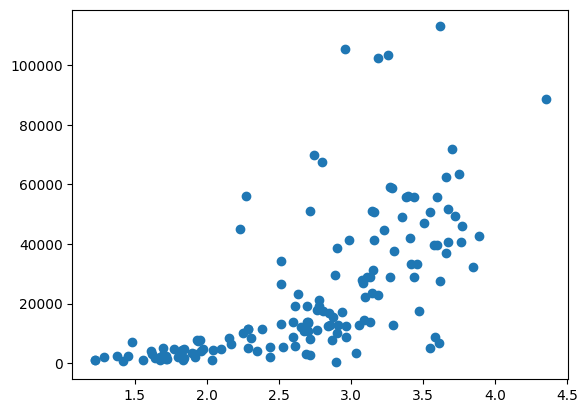

In [7]:
plt.scatter(x = pwt2019['hc'], y = pwt2019['rgdpe_per_pers'])
plt.show()

In [9]:
from cycler import cycler

plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams["axes.labelsize"]= 12
plt.rcParams["figure.facecolor"] = "#f2f2f2"
# plt.rcParams['figure.savefig.dpi'] = 100
plt.rcParams['savefig.edgecolor'] = "#f2f2f2"
plt.rcParams['savefig.facecolor'] ="#f2f2f2"
plt.rcParams["figure.figsize"] = [16, 10]
plt.rcParams['savefig.bbox'] = "tight"
plt.rcParams['font.size'] = 14
greens = ['#66c2a4','#41ae76','#238b45','#006d2c','#00441b']
multi = ['#66c2a4','#1f78b4','#a6cee3','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f']
plt.rcParams["axes.prop_cycle"] = cycler(color = multi)

Text(0, 0.5, 'Real GDP Per Person')

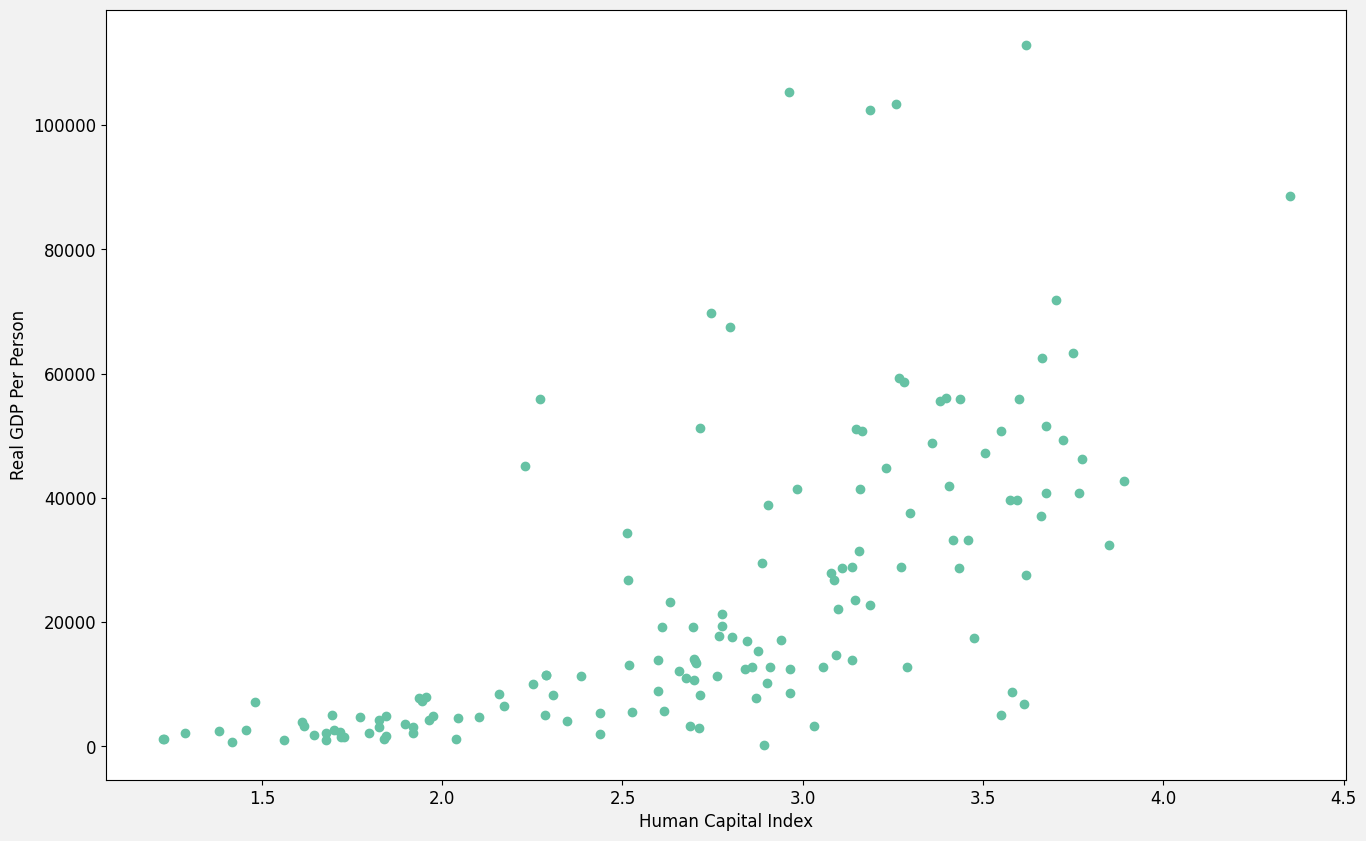

In [10]:
fig, ax = plt.subplots()
ax.scatter(pwt2019['hc'], pwt2019['rgdpe_per_pers'])
ax.set_xlabel('Human Capital Index')
ax.set_ylabel('Real GDP Per Person')

In [11]:
outliers = pwt2019.loc[pwt2019['rgdpe_per_pers'] > 80000, ['hc', 'rgdpe_per_pers', 'country']]
outliers

,hc,rgdpe_per_pers,country
5599,3.185517,102353.631453,Ireland
7209,3.619643,112941.453350,Luxembourg
7349,2.962418,105337.890061,"China, Macao SAR"
9799,3.259456,103445.127287,Qatar
10289,4.351568,88619.305271,Singapore


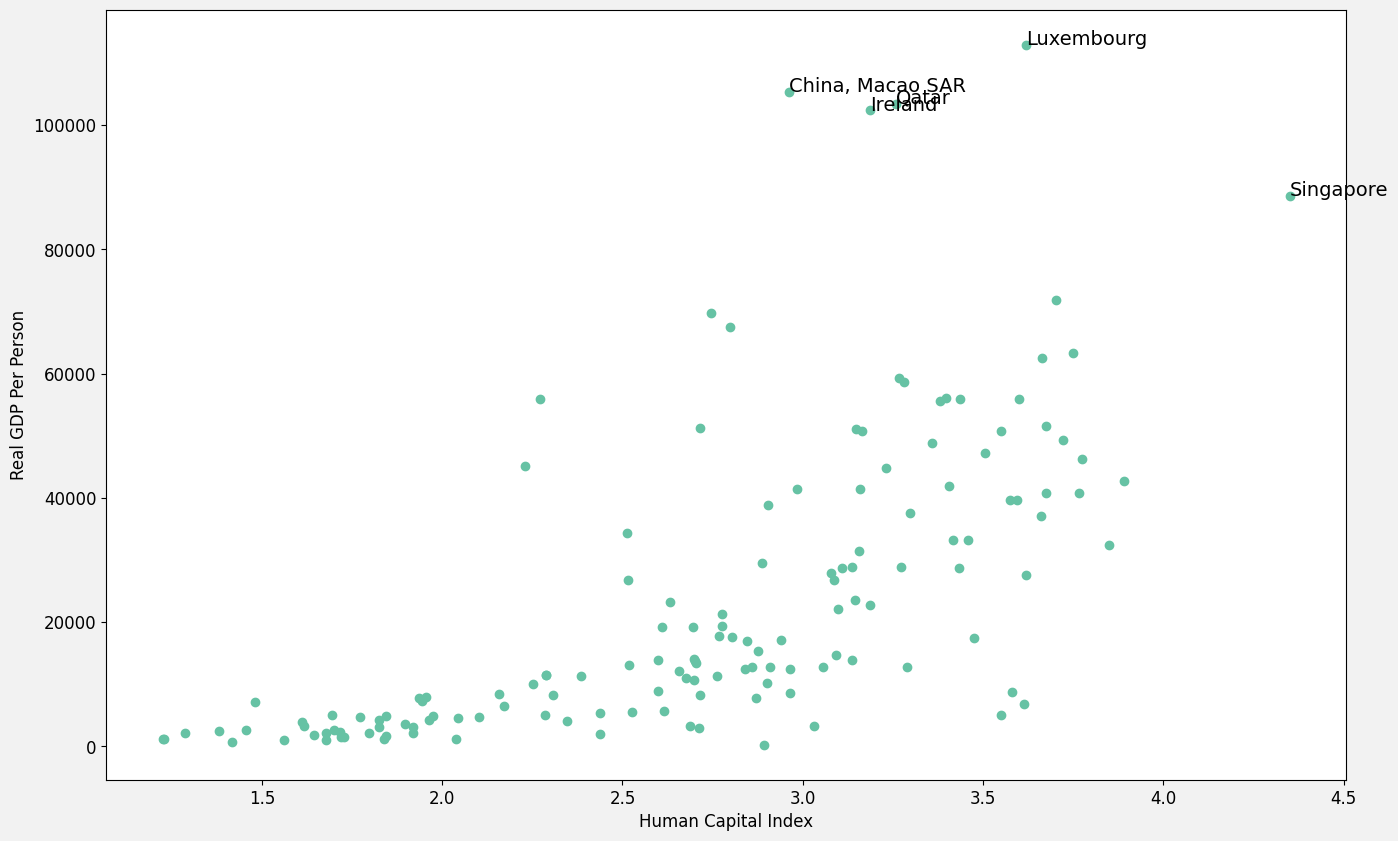

In [12]:
fig, ax = plt.subplots()
ax.scatter(pwt2019['hc'], pwt2019['rgdpe_per_pers'])
ax.set_xlabel('Human Capital Index')
ax.set_ylabel('Real GDP Per Person')
for index, outlier in outliers.iterrows():
    ax.text(outlier['hc'], outlier['rgdpe_per_pers'], outlier['country'])

Using the natural logarithm to transform the data for the purpose of linearizing the relationship and minimizing outliers.

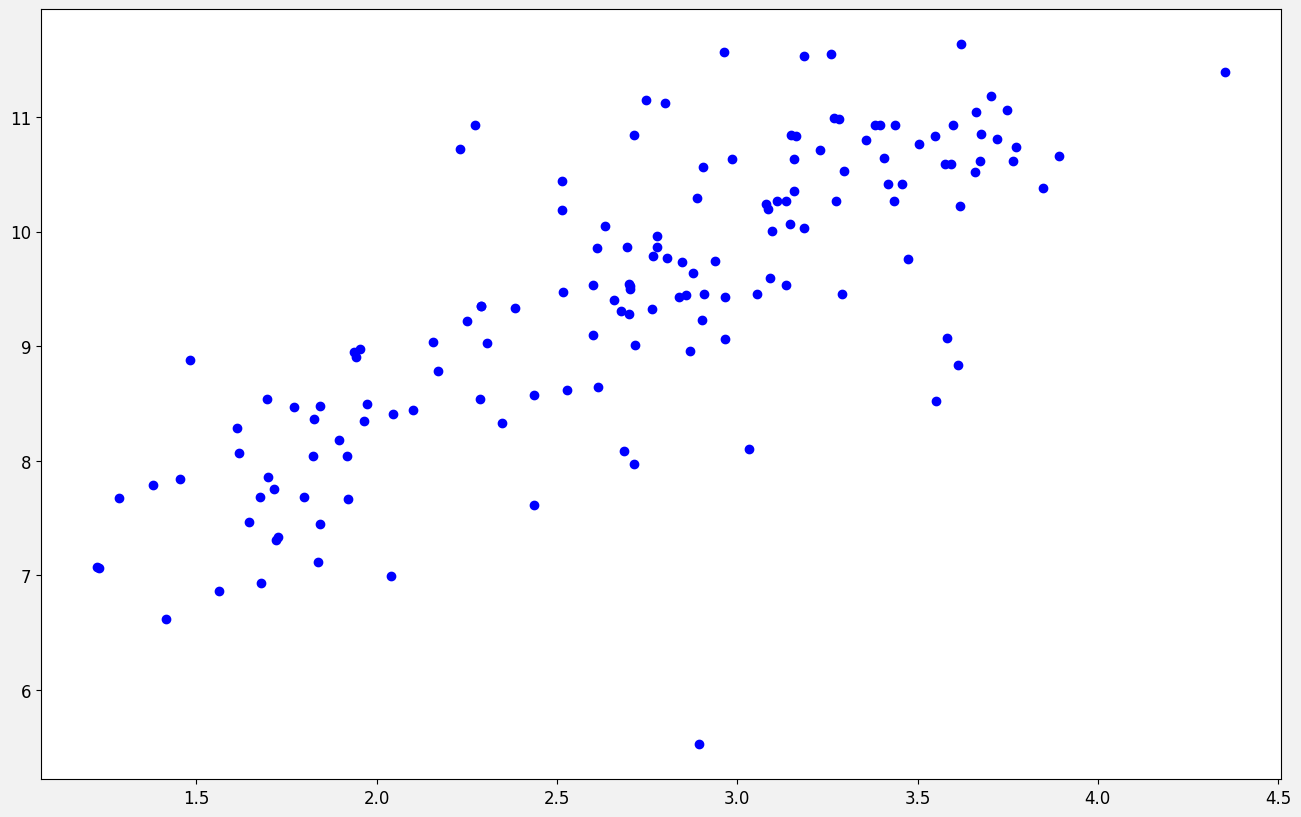

In [14]:
fig, ax = plt.subplots()
ax.scatter(pwt2019['hc'], np.log(pwt2019['rgdpe_per_pers']), color = 'blue')
plt.show()

Now a ln transformation on both axes:

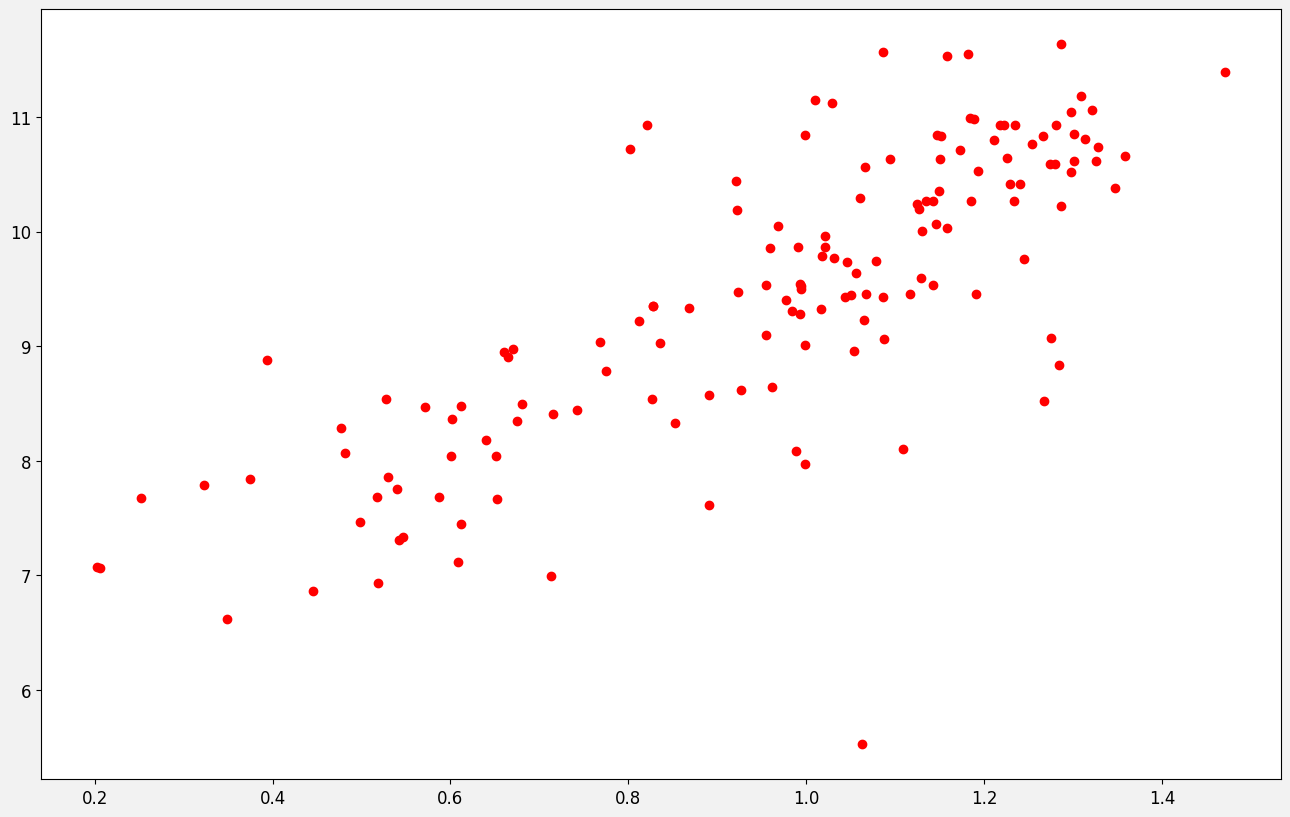

In [15]:
fig, ax = plt.subplots()
ax.scatter(np.log(pwt2019['hc']), np.log(pwt2019['rgdpe_per_pers']), color = 'red')
plt.show()

Making 2d plots represent 3d data.

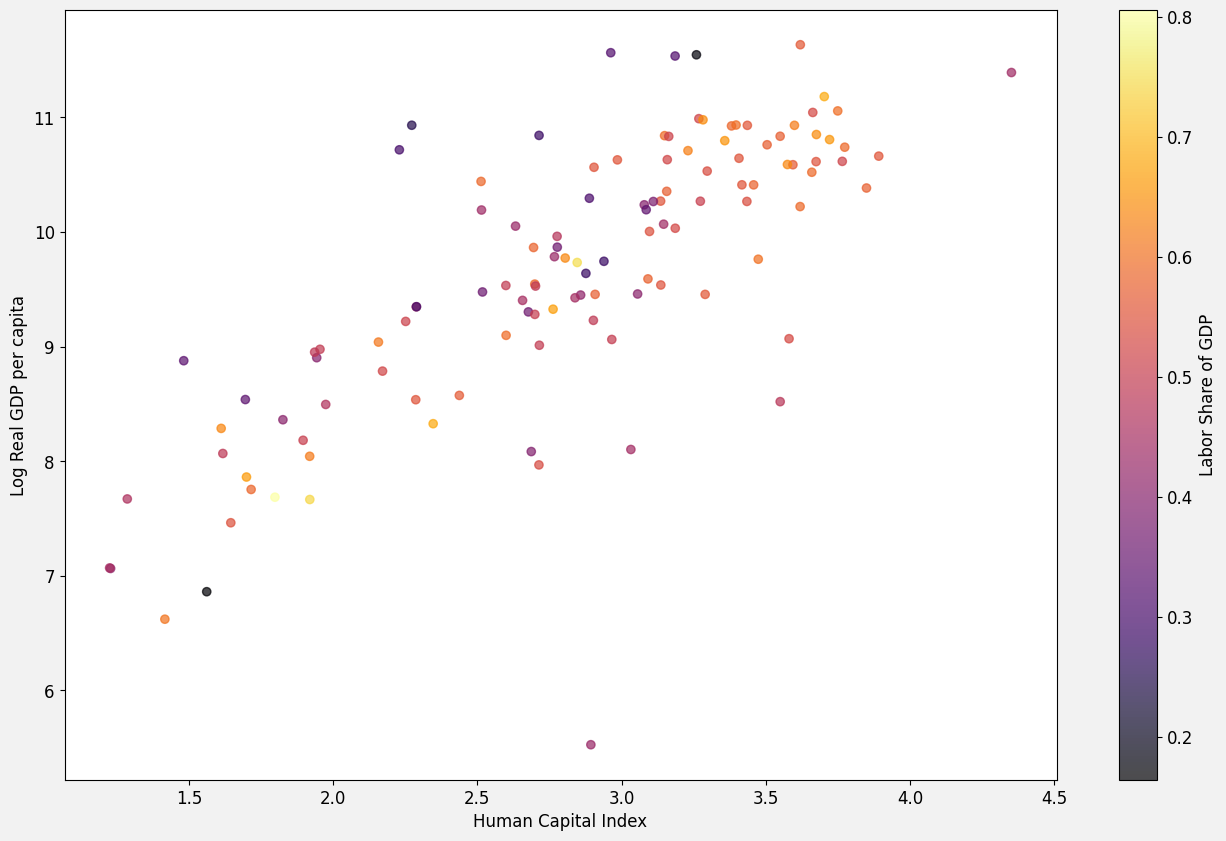

In [27]:
fig, ax = plt.subplots()
s = ax.scatter(pwt2019['hc'], np.log(pwt2019['rgdpe_per_pers']), c = pwt2019['labsh'], cmap = 'inferno', alpha = .7)
ax.set_xlabel('Human Capital Index')
ax.set_ylabel('Log Real GDP per capita')
colorbar = plt.colorbar(s, ax = ax)
colorbar.set_label('Labor Share of GDP')

In [26]:
largeCountries = pwt2019.loc[pwt2019['pop'] > 250]
largeCountries

,countrycode,country,currency_unit,year,rgdpe,rgdpo,pop,emp,avh,hc,ccon,cda,cgdpe,cgdpo,cn,ck,ctfp,cwtfp,rgdpna,rconna,rdana,rnna,rkna,rtfpna,rwtfpna,labsh,irr,delta,xr,pl_con,pl_da,pl_gdpo,i_cig,i_xm,i_xr,i_outlier,i_irr,cor_exp,statcap,csh_c,csh_i,csh_g,csh_x,csh_m,csh_r,pl_c,pl_i,pl_g,pl_x,pl_m,pl_n,pl_k,rgdpe_per_pers
2379,CHN,China,Yuan Renminbi,2019,20056066.00,20257660.0,1433.783686,798.807739,2168.918848,2.698987,10566063.00,19703060.0,19919016.0,20118076.00,101544168.0,1.167075,0.400480,0.377223,20572606.0,12331125.0,21638008.00,101703024.0,1.175672,0.966811,1.048805,0.586253,0.075134,0.051895,6.908385,0.755530,0.720062,0.712938,Extrapolated,Extrapolated,Market-based,Regular,Regular,NaN,80.000000,0.387516,0.454168,0.137686,0.192402,-0.167672,-0.004101,0.716501,0.679048,0.865375,0.695068,0.734048,0.457010,0.588816,13988.209097
5459,IDN,Indonesia,Rupiah,2019,3104438.75,3137931.0,270.625568,131.170685,2019.923395,2.288165,2051190.25,3101039.0,3087351.0,3120405.75,18173848.0,0.182559,0.444861,0.425198,3110469.5,2050129.5,3119241.75,17785758.0,1.127282,1.010216,1.010776,0.463751,0.107771,0.041685,14147.671360,0.363814,0.362508,0.358668,Extrapolated,Extrapolated,Market-based,Regular,Regular,NaN,88.888900,0.550961,0.336446,0.106387,0.089377,-0.081947,-0.001223,0.377086,0.359957,0.295082,0.601248,0.669811,0.213909,0.380692,11471.343129
5529,IND,India,Indian Rupee,2019,8945547.00,9170555.0,1366.417754,497.615723,2122.940682,2.171165,6608023.50,9079422.0,8900328.0,9142121.00,35324124.0,0.416540,0.438098,0.418459,9163052.0,6603997.5,9091771.00,35423256.0,1.129737,1.020127,0.999347,0.521804,0.124115,0.057050,70.419969,0.312882,0.324885,0.316292,Extrapolated,Extrapolated,Market-based,Regular,Regular,NaN,75.555567,0.649357,0.270331,0.073454,0.051035,-0.077878,0.033701,0.294905,0.356979,0.471800,0.692824,0.672622,0.210068,0.384406,6546.714556
12179,USA,United States,US Dollar,2019,20860506.00,20595844.0,329.064917,158.299591,1765.346390,3.749341,16826236.00,21383552.0,20791364.0,20566034.00,69059088.0,1.000000,1.000000,1.000000,20563592.0,16803152.0,21436590.00,69059064.0,1.045882,1.016862,1.019682,0.597091,0.072846,0.045965,1.000000,1.042399,1.030872,1.042166,Extrapolated,Extrapolated,Market-based,Regular,Regular,NaN,NaN,0.703201,0.221594,0.114955,0.111490,-0.165832,0.014591,1.005707,0.988310,1.266850,0.717118,0.752818,1.069460,1.000000,63393.284797


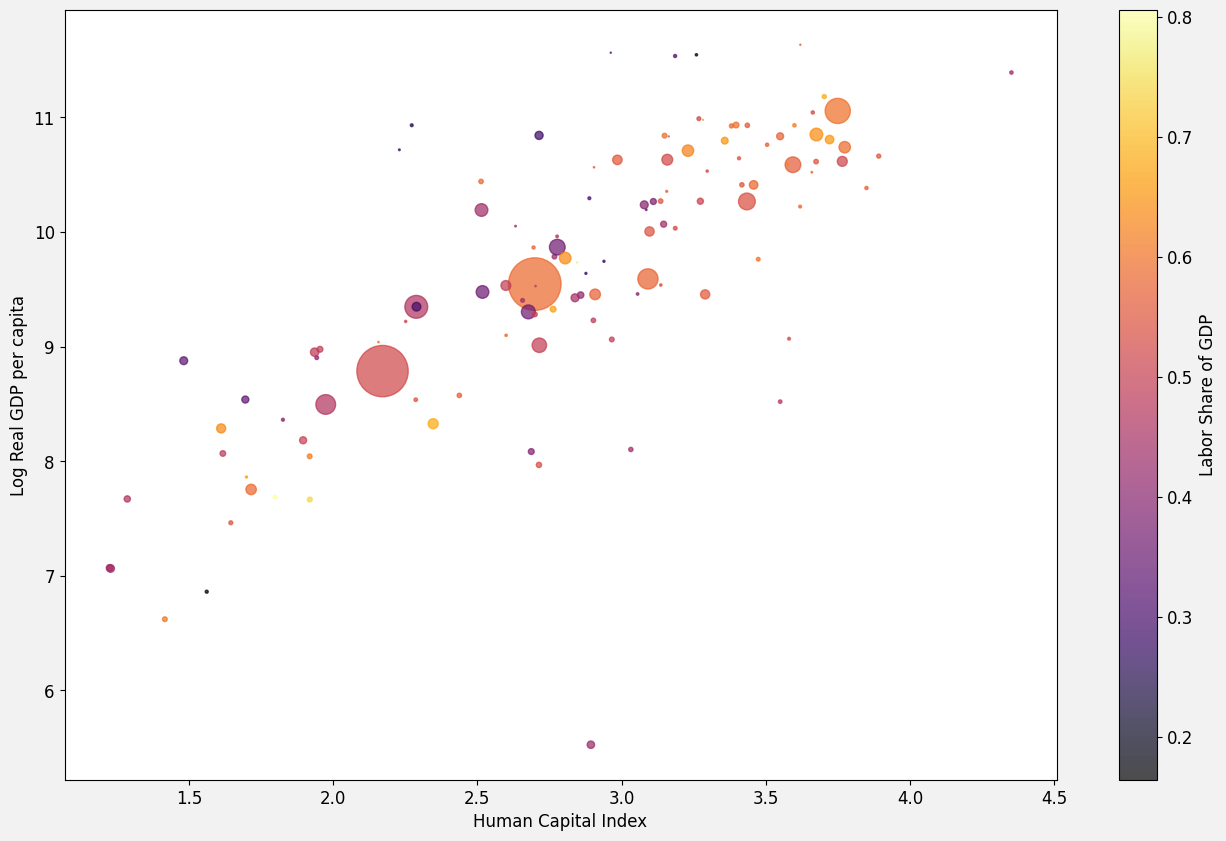

In [28]:
fig, ax = plt.subplots()
s = ax.scatter(pwt2019['hc'], np.log(pwt2019['rgdpe_per_pers']), c = pwt2019['labsh'], cmap = 'inferno', s = pwt2019['pop'], alpha = .7)
ax.set_xlabel('Human Capital Index')
ax.set_ylabel('Log Real GDP per capita')
colorbar = plt.colorbar(s, ax = ax)
colorbar.set_label('Labor Share of GDP')